# Stroke Prediction Dataset

Advanced Classification and Clustering on Stroke Prediction Dataset Using Cluster-Based Label Engineering

Loading data and libraries

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "fedesoriano/stroke-prediction-dataset"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [9]:
import os

csv_path = os.path.join(
    path,
    "healthcare-dataset-stroke-data.csv"
)

df = pd.read_csv(csv_path)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df.shape

(5110, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Check missing values

In [12]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


2. Check imbalance

In [13]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


binary classification (0 and 1)

In [14]:
df['stroke'].value_counts(normalize=True)

,proportion
stroke,
0,0.951272
1,0.048728


PREPROCESSING

Encode categorical variables into numeric

In [15]:
df_encoded = pd.get_dummies(df)

Handle missing values using KNNImputer

In [16]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

df_impute = pd.DataFrame(
    imputer.fit_transform(df_encoded),
    columns=df_encoded.columns
)

In [17]:
X = df_impute.drop('stroke', axis=1)
y = df_impute['stroke']

Handle imbalance using SMOTE

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)

X, y = smote.fit_resample(X, y)

Train-test split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

Train Baseline model using Decision Tree classification

In [20]:
from sklearn.tree import DecisionTreeClassifier

model_baseline = DecisionTreeClassifier()

model_baseline.fit(X_train, y_train)

DecisionTreeClassifier()

Prediction

In [21]:
y_pred = model_baseline.predict(X_test)

Evaluation

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9410353102502571
[[1357   93]
 [  79 1388]]
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94      1450
         1.0       0.94      0.95      0.94      1467

    accuracy                           0.94      2917
   macro avg       0.94      0.94      0.94      2917
weighted avg       0.94      0.94      0.94      2917



OVERFITTING TEST by comparing train_acc with test_acc

In [23]:
train_acc = model_baseline.score(X_train, y_train)
test_acc = model_baseline.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9410353102502571


The baseline model achieved a training accuracy of 100% and a testing accuracy of approximately 94%. The small performance gap suggests that the model generalizes reasonably well to unseen data, although the perfect training accuracy may indicate some degree of overfitting.






## PART 2 FEATURE ENGINEERING USING CLUSTERING

I remove the original target

In [24]:
X_cluster = X.copy()

In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)

cluster_labels = kmeans.fit_predict(X_cluster)

In [26]:
cluster_labels

array([2, 1, 0, ..., 2, 1, 1], dtype=int32)

## PART 3 SECOND CLASSIFICATION MODEL

New target variable

In [27]:
y_new = cluster_labels

Train-test spilt

In [28]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y_new,
    test_size=0.3,
    random_state=0
)

Train second model

In [29]:
model_cluster = DecisionTreeClassifier()

model_cluster.fit(X_train2, y_train2)

DecisionTreeClassifier()

Prediction

In [30]:
y_pred2 = model_cluster.predict(X_test2)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test2, y_pred2))

print(confusion_matrix(y_test2, y_pred2))

print(classification_report(y_test2, y_pred2))

Accuracy: 1.0
[[1047    0    0]
 [   0 1013    0]
 [   0    0  857]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1047
           1       1.00      1.00      1.00      1013
           2       1.00      1.00      1.00       857

    accuracy                           1.00      2917
   macro avg       1.00      1.00      1.00      2917
weighted avg       1.00      1.00      1.00      2917



Overfitting analysis

In [32]:
train_acc2 = model_cluster.score(
    X_train2,
    y_train2
)

test_acc2 = model_cluster.score(
    X_test2,
    y_test2
)

print("Training Accuracy:", train_acc2)

print("Testing Accuracy:", test_acc2)

Training Accuracy: 1.0
Testing Accuracy: 1.0


**Stroke Distribution Plot**

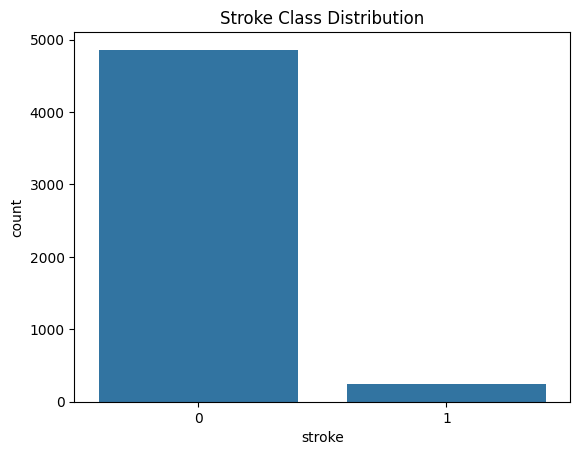

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='stroke', data=df)

plt.title('Stroke Class Distribution')
plt.show()

**Baseline Model Confusion Matrix**

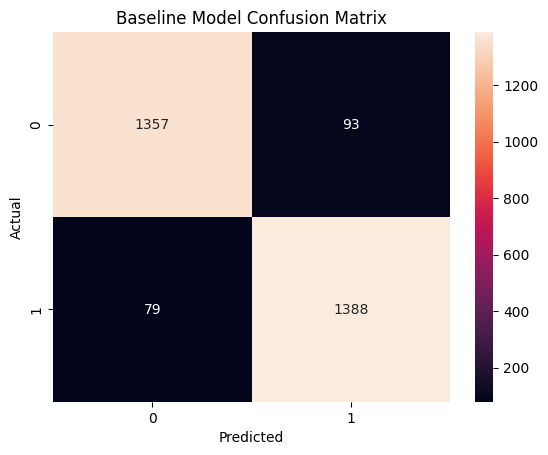

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Cluster Distribution**

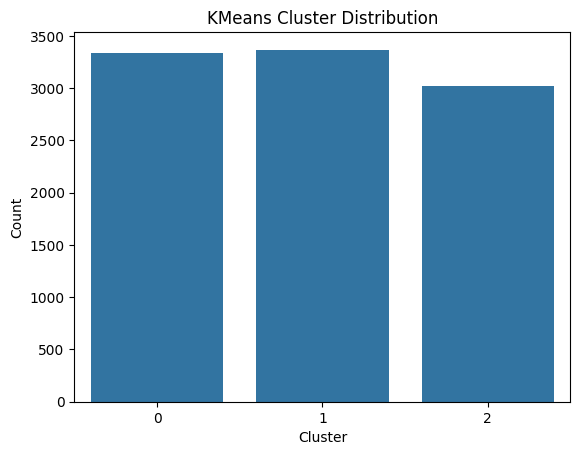

In [35]:
sns.countplot(x=cluster_labels)

plt.title('KMeans Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Count')

plt.show()

The second classification model was trained using cluster-generated labels obtained from KMeans clustering. Compared to the original baseline model, The second classification model was trained using cluster-generated labels obtained from KMeans clustering. The model achieved perfect classification performance when predicting the generated cluster labels. This result is expected because the cluster labels were created directly from the same feature space used for training. This demonstrates how unsupervised learning can be combined with supervised learning through cluster-based label engineering to discover and classify hidden patterns within the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
